# TICKETS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk import FreqDist
from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA
from wordcloud import WordCloud

In [2]:
df =  pd.read_excel("FreshDeskTickets.xlsx")

In [ ]:
df.head()

In [4]:
df.columns

Index(['AccountId', 'CreatedAt', 'Deleted', 'Delta', 'Description', 'Dirty',
       'DisplayId', 'DueBy', 'FrDueBy', 'FrEscalated', 'GroupId', 'Id',
       'IsEscalated', 'NrEscalated', 'NrReminded', 'OwnerId', 'Priority',
       'RequesterId', 'ResponderId', 'SlaState', 'Source', 'Spam', 'Status',
       'Subject', 'TicketType', 'Trained', 'UpdatedAt', 'Urgent', 'StatusName',
       'RequesterStatusName', 'PriorityName', 'SourceName', 'RequesterName',
       'ResponderName', 'ProductId'],
      dtype='object')

In [5]:
df = df.loc[:,["CreatedAt","UpdatedAt","DueBy","FrDueBy","Source","TicketType","RequesterId","ResponderName","Description","PriorityName","StatusName"]]

In [ ]:
df

In [ ]:
list(df["ResponderName"].value_counts().index)

In [ ]:
df.head()

In [9]:
df["TicketType"].value_counts()

Enquiry            37308
Request             7361
Other               4073
Complaint           1751
Sales               1483
Follow up            791
Feature Request       30
Name: TicketType, dtype: int64

In [10]:
df["PriorityName"].value_counts()

Low       61470
Medium       22
Urgent        7
High          7
Name: PriorityName, dtype: int64

In [11]:
df["Description"] = df["Description"].apply(str)

In [12]:
df["Description"] = df.Description.str.replace('@[A-Za-z0-9]+','')
df["Description"] = df.Description.str.replace('_[A-Za-z0-9]+','')
df["Description"] = df.Description.str.replace('_','')
df["Description"] = df.Description.str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))','')

C:\Users\user\.conda\envs\tensorflow\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  """Entry point for launching an IPython kernel.
C:\Users\user\.conda\envs\tensorflow\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  
C:\Users\user\.conda\envs\tensorflow\lib\site-packages\ipykernel_launcher.py:4: FutureWarning: The default value of regex will change from True to False in a future version.
  after removing the cwd from sys.path.


In [13]:
df['UpdatedAt'] = pd.to_datetime(df['UpdatedAt'])
df.set_index(df['UpdatedAt'],inplace=True)
df.drop(columns=['UpdatedAt'],inplace=True)
df.sort_index(inplace=True)
df.head(10)

# Word Clouds funtion(s)

In [14]:
def word_cloud_disc(text):
    #We get the directory that we are working on
    x, y = np.ogrid[:300, :300]
    mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
    mask = 255 * mask.astype(int)
    #We read the mask image into a numpy array
    #avengers_mask = np.array(Image.open(os.path.join(file, "avengers.png")))
    #We generate the wordcloud using the series created and the mask 
    word_cloud = WordCloud(width=2000, height=1000, max_font_size=200, 
                           background_color="black", max_words=2000, mask=mask, 
                           contour_width=1, contour_color="steelblue", 
                           colormap="nipy_spectral").generate(text)

    #Now we plot the figure
    plt.figure(figsize=(10,10))
    plt.imshow(word_cloud, interpolation="hermite")
    plt.axis("off")    
    plt.show()

In [15]:
def word_cloud_box(data):
    plt.figure(figsize = (100,100))
    word_cloud = WordCloud(background_color = 'white', max_words = 1000,  max_font_size = 50)
    word_cloud.generate(data)
    plt.imshow(word_cloud)
    plt.axis('off')

# Word Clouds - Overal Archived Tickets Sentiment

* **Disk**

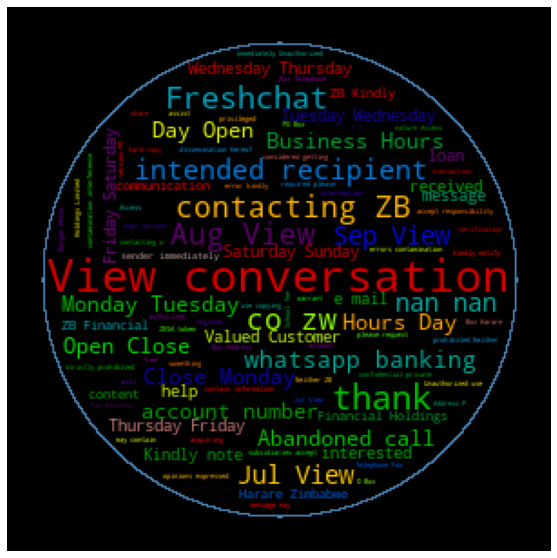

In [16]:
word_cloud_disc(pd.Series([text for text in df.Description]).str.cat(sep=' '))

* **Box**

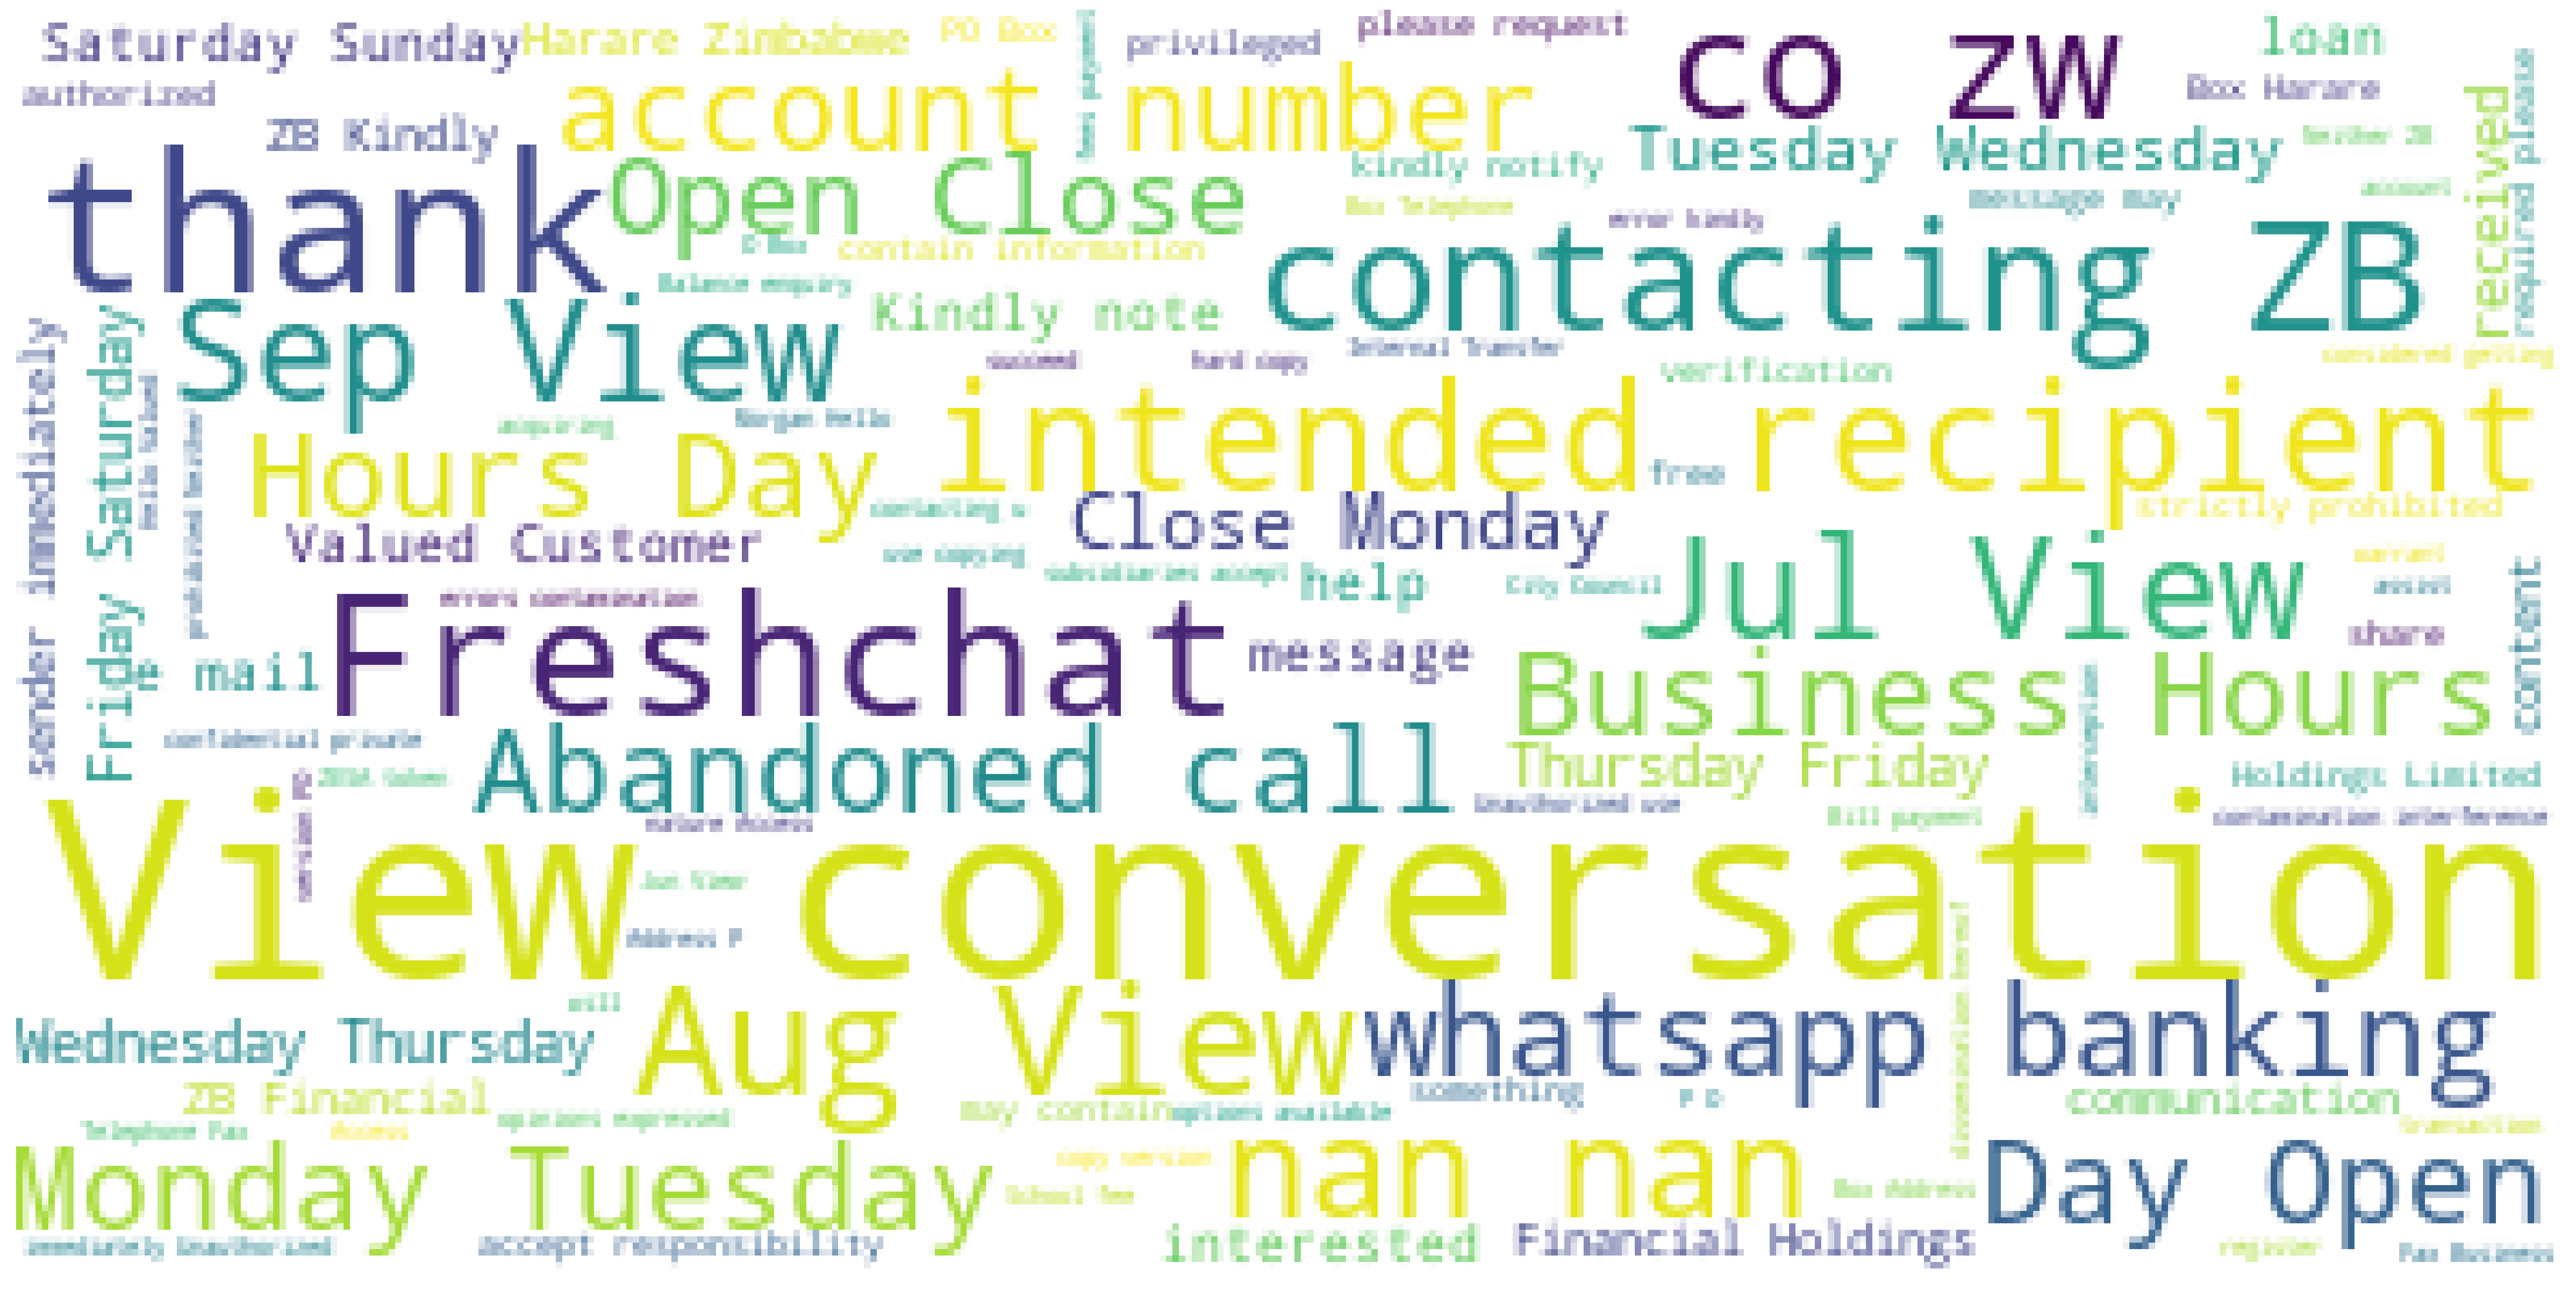

In [17]:
word_cloud_box(pd.Series([text for text in df.Description]).str.cat(sep=' '))

# Sentiment Intensity Analyzer (SIA)

#### VADER Sentiment Analysis :

**VADER (Valence Aware Dictionary and sEntiment Reasoner)** is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media. VADER uses a combination of A sentiment lexicon is a list of lexical features (e.g., words) which are generally labeled according to their semantic orientation as either positive or negative. VADER not only tells about the Positivity and Negativity score but also tells us about how positive or negative a sentiment is.

**Why sentiment analysis?**

* **Business:** In marketing field companies use it to develop their strategies, to understand customers’ feelings towards products or brand, how people respond to their campaigns or product launches and why consumers don’t buy some products.

* **Politics:** In the political field, it is used to keep track of political view, to detect consistency and inconsistency between statements and actions at the government level. It can be used to predict election results as well! .

* **Public Actions:** Sentiment analysis also is used to monitor and analyse social phenomena, for the spotting of potentially dangerous situations and determining the general mood of the blogosphere.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61506 entries, 2021-11-07 to 2022-09-20
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CreatedAt      61506 non-null  datetime64[ns]
 1   DueBy          61506 non-null  datetime64[ns]
 2   FrDueBy        61506 non-null  datetime64[ns]
 3   Source         61506 non-null  int64         
 4   TicketType     52797 non-null  object        
 5   RequesterId    61506 non-null  int64         
 6   ResponderName  61506 non-null  object        
 7   Description    61506 non-null  object        
 8   PriorityName   61506 non-null  object        
 9   StatusName     61506 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(5)
memory usage: 5.2+ MB


In [19]:
sia = SIA()
pol_score_list = list()
for tweet in df.Description:
    sent = sia.polarity_scores(tweet)
    pol_score_list.append(sent)

In [ ]:
pol = pd.DataFrame(pol_score_list)
pol = pol[['neg','neu','pos','compound']]
pol.set_index(df.index,inplace = True)
pol.columns = ['negative','neutral','positive','compound']
df_final = pd.concat([df,pol],axis='columns')
df_final.head()

In [21]:
df["TicketType"].nunique()

7

In [22]:
df.shape

(61506, 10)

In [ ]:
df_final['sentiment']=np.where(df_final['compound']<0,"negative",np.where(df_final['compound']>0,"positive","neutral"))
df_final.head()

In [24]:
df_final.nunique()

CreatedAt          199
DueBy              167
FrDueBy            175
Source               7
TicketType           7
RequesterId      40396
ResponderName       29
Description      37376
PriorityName         4
StatusName           6
negative           407
neutral            584
positive           527
compound          2790
sentiment            3
dtype: int64

In [25]:
df_final.shape

(61506, 15)

In [26]:
df_final.drop_duplicates(inplace=True)

In [27]:
df_final.shape

(60371, 15)

# Counting sentiment per category

In [28]:
val_counts = pd.DataFrame(df_final.sentiment.value_counts())
val_counts

,sentiment
neutral,27728
positive,26110
negative,6533


### A pie chart to show sentiment distribution

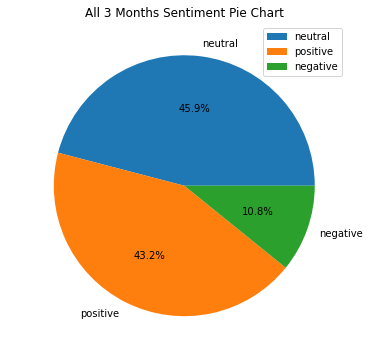

In [29]:
val_counts.plot(kind='pie',subplots=True,figsize=(8,6),autopct='%1.1f%%')
plt.title('All 3 Months Sentiment Pie Chart')
plt.ylabel(" ")
plt.legend(loc = 'upper right')
plt.show()

### Positive to nagative sentiment ditribution

In [30]:
pos_and_neg = pd.DataFrame(df_final[df_final['sentiment']!= 'neutral']['sentiment'].value_counts(normalize=True))
pos_and_neg

,sentiment
positive,0.799865
negative,0.200135


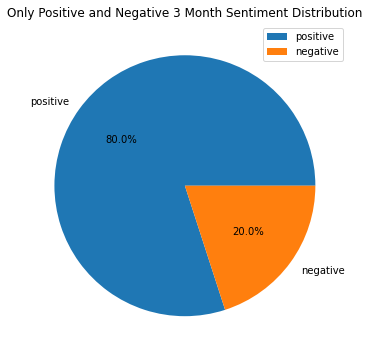

In [31]:
pos_and_neg.plot(kind='pie',subplots=True,figsize=(8,6),autopct='%1.1f%%')
plt.title('Only Positive and Negative 3 Month Sentiment Distribution')
plt.ylabel(" ")
plt.legend(loc = 'upper right')
plt.show()

# splitting tweets by category

In [32]:
pos_tweets = df_final[df_final['sentiment']=='positive']
neg_tweets = df_final[df_final['sentiment']=='negative']
neu_tweets = df_final[df_final['sentiment']=='neutral']

## word cloud for positive tweets

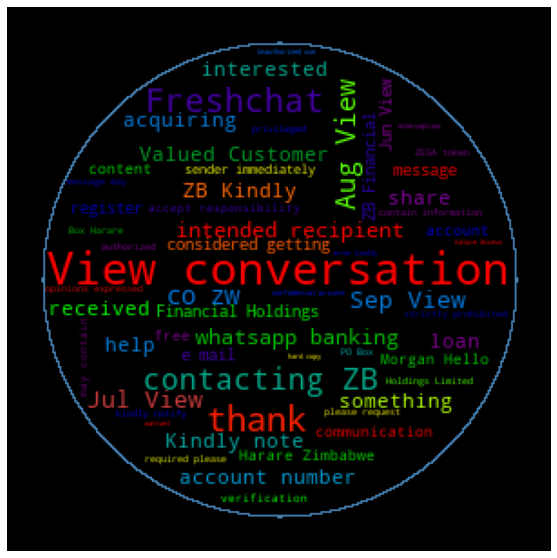

In [33]:
word_cloud_disc(pd.Series([text for text in pos_tweets.Description]).str.cat(sep=' '))

## word cloud for negative tweets

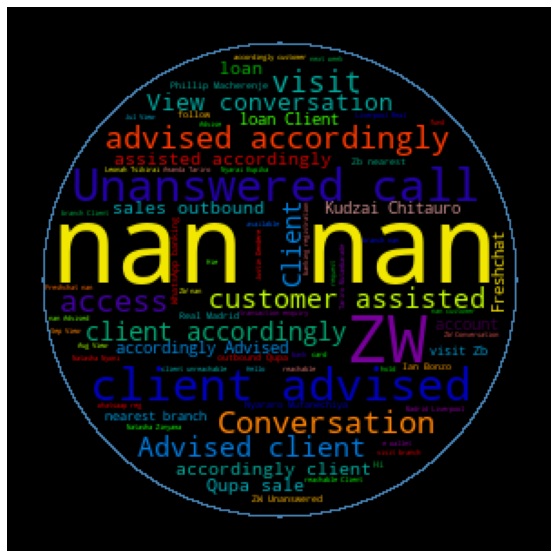

In [34]:
word_cloud_disc(pd.Series([text for text in neu_tweets.Description]).str.cat(sep=' '))

In [ ]:
for i in neg_tweets.iloc[:,:10].Description:
    print(i)

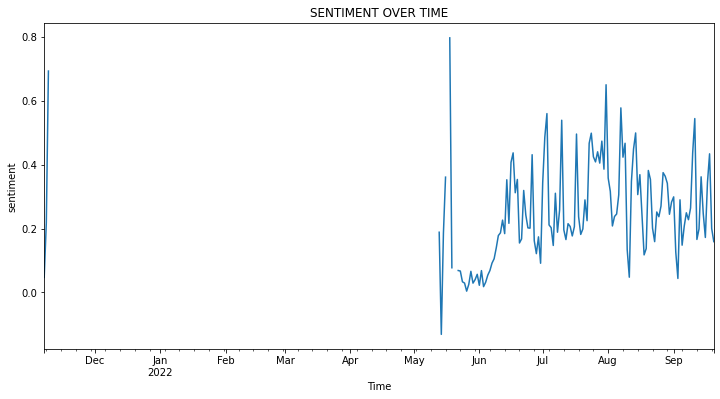

In [36]:
df_final['compound'].resample("D").mean().plot(figsize = (12,6))
plt.title("SENTIMENT OVER TIME")
plt.xlabel("Time")
plt.ylabel("sentiment")
plt.show()